In [33]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF, Matern, RationalQuadratic, DotProduct

import globals

importlib.reload(globals)

<module 'globals' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Masters_Thesis\\globals.py'>

In [34]:
gp_results = pickle.load(open("./gp_saves/model_saves/gp_results_500.pkl", "rb"))
gp_results[0]["gpr_list"][0].kernel_

1.02**2 * RBF(length_scale=[5.78, 1.29, 1.17, 2.57, 1.33, 10.5, 1.06, 4.75, 1.85]) + WhiteKernel(noise_level=3.69e-05)

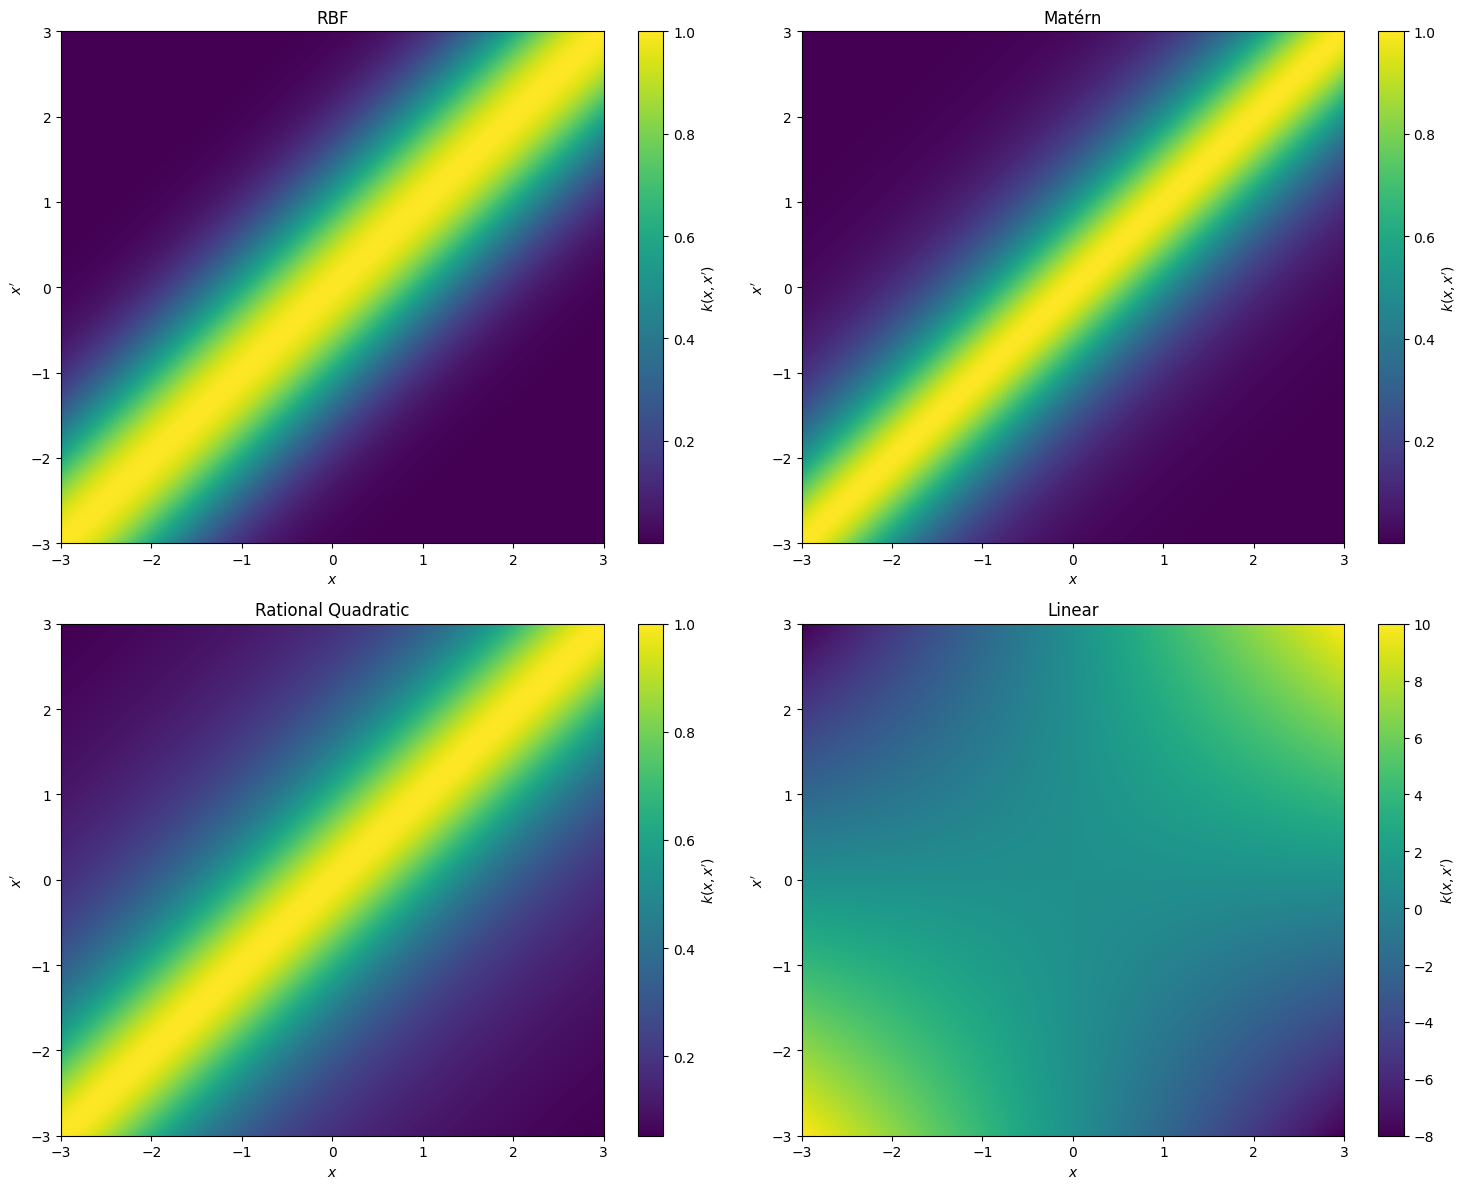

In [38]:
# choose the input dimension to visualize
input_dim = 0

# number of points along the 1D slice
n_points = 300

# range of the slice; change these if your inputs are not standardized
x_min = -3.0
x_max = 3.0

# fixed values for all dimensions except input_dim
x_fixed = np.zeros(globals.N_INPUTS)

# construct a 1D slice through the input space
x_values = np.linspace(x_min, x_max, n_points)
X_slice = np.tile(x_fixed, (n_points, 1))
X_slice[:, input_dim] = x_values

# kernels without WhiteKernel
kernels = {
    "RBF": C(1.0) * RBF(length_scale=np.ones(globals.N_INPUTS)),
    "Matérn": C(1.0) * Matern(length_scale=np.ones(globals.N_INPUTS), nu=2.5),
    "Rational Quadratic": C(1.0) * RationalQuadratic(length_scale=1.0, alpha=1.0),
    "Linear": C(1.0) * DotProduct()
}

gp_results = pickle.load(open("./gp_saves/model_saves/gp_results_500.pkl", "rb"))

# create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

# generate one heatmap per kernel
for ax, (name, kernel) in zip(axes, kernels.items()):
    K = kernel(X_slice, X_slice)

    im = ax.imshow(
        K,
        origin="lower",
        extent=[x_min, x_max, x_min, x_max],
        aspect="auto"
    )

    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$x'$")
    ax.set_title(name)

    # individual colorbar for each subplot
    fig.colorbar(im, ax=ax, label=r"$k(x,x')$")

plt.tight_layout()
plt.savefig("gp_saves/kernel_visualizations.png", dpi=300, bbox_inches="tight")
plt.show()

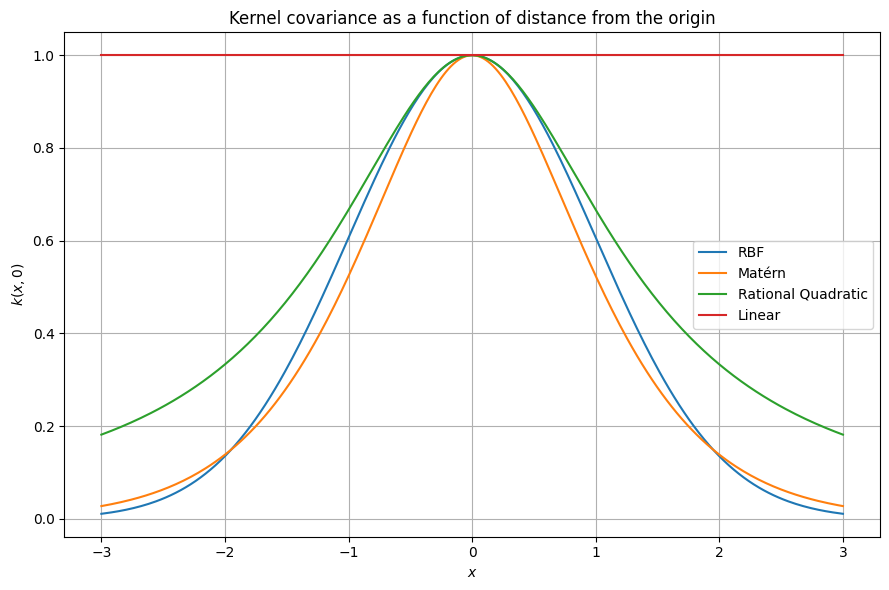

In [39]:
plt.figure(figsize=(9, 6))

x_ref = np.zeros(globals.N_INPUTS)

for name, kernel in kernels.items():
    K_ref = kernel(X_slice, x_ref.reshape(1, -1)).ravel()
    plt.plot(x_values, K_ref, label=name)

plt.xlabel(r"$x$")
plt.ylabel(r"$k(x,0)$")
plt.title("Kernel covariance as a function of distance from the origin")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("gp_saves/kernel_covariance_0.png", dpi=300, bbox_inches="tight")
plt.show()

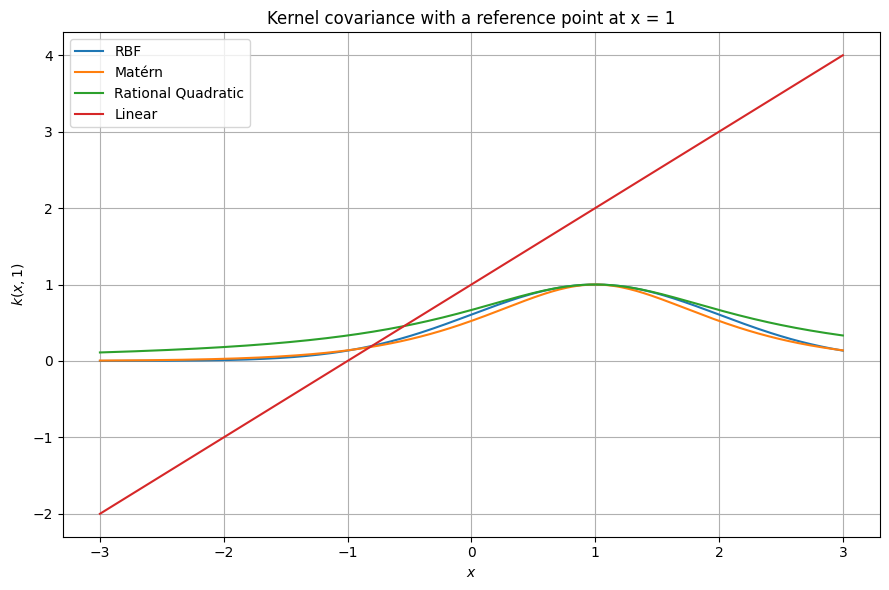

In [40]:
plt.figure(figsize=(9, 6))

x_ref = np.zeros(globals.N_INPUTS)
x_ref[input_dim] = 1.0

for name, kernel in kernels.items():
    K_ref = kernel(X_slice, x_ref.reshape(1, -1)).ravel()
    plt.plot(x_values, K_ref, label=name)

plt.xlabel(r"$x$")
plt.ylabel(r"$k(x,1)$")
plt.title("Kernel covariance with a reference point at x = 1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("gp_saves/kernel_covariance_1.png", dpi=300, bbox_inches="tight")
plt.show()